In [1]:
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Spatial
from scipy.spatial.distance import cdist

# Gaussian Processes
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel

# Time series (convex)
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Utilities
from tqdm import tqdm
from datetime import datetime, timedelta
from sklearn.preprocessing import OneHotEncoder


In [3]:
df = pd.read_csv('/content/data_encoded.csv')
df.head()

,timestamp,sensor_id,sensor_type,location,lat,lon,PM10,PM2_5,humidity,temperature,date,hour,day_of_week,day_of_month
0,2018-09-01 00:00:02.472867+00:00,57.0,SDS011,29.0,-1.300,36.785,39.67,34.43,NaN,NaN,2018-09-01,0.0,Saturday,1.0
1,2018-09-01 00:00:04.301785+00:00,58.0,DHT22,29.0,-1.300,36.785,NaN,NaN,83.4,16.5,2018-09-01,0.0,Saturday,1.0
2,2018-09-01 00:00:07.536156+00:00,69.0,SDS011,7.0,-1.298,36.791,18.47,16.63,NaN,NaN,2018-09-01,0.0,Saturday,1.0
3,2018-09-01 00:00:08.902190+00:00,70.0,DHT22,7.0,-1.298,36.791,NaN,NaN,56.5,21.7,2018-09-01,0.0,Saturday,1.0
4,2018-09-01 00:00:26.722032+00:00,40.0,SDS011,7.0,-1.298,36.791,21.52,19.30,NaN,NaN,2018-09-01,0.0,Saturday,1.0


In [4]:
df[['PM10', 'PM2_5', 'humidity', 'temperature']].describe()


,PM10,PM2_5,humidity,temperature
count,13344.000000,13344.000000,8801.000000,8801.000000
mean,20.946596,12.502095,77.022486,18.176071
std,19.857032,11.281805,11.329613,2.165912
min,1.920000,1.550000,42.000000,13.800000
25%,11.230000,6.900000,66.200000,16.300000
50%,16.640000,10.300000,77.800000,18.200000
75%,24.600000,15.030000,87.200000,19.800000
max,597.730000,336.770000,97.900000,28.700000


In [5]:
df["timestamp"].apply(type).value_counts()

df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce",   # invalid parsing → NaT
    utc=True           # handles +00:00 safely
)
df["timestamp"].isna().sum()
df = df.dropna(subset=["timestamp"])
df["timestamp"] = df["timestamp"].dt.tz_convert(None)
df.columns
df["timestamp"].dtype
df["timestamp"].isna().sum()

df = df.dropna(subset=["timestamp"])
df_pm = df[df["sensor_type"] == "SDS011"]
df_met = df[df["sensor_type"] == "DHT22"]


In [6]:
df_merged = pd.merge_asof(
    df_pm.sort_values("timestamp"),
    df_met.sort_values("timestamp"),
    on="timestamp",
    by=["location", "lat", "lon"],
    tolerance=pd.Timedelta("1min"),
    direction="nearest",
    suffixes=("", "_met")
)
df_final = df_merged[
    ["timestamp", "sensor_id", "lat", "lon",
     "PM2_5", "temperature_met", "humidity_met",
     "hour", "day_of_week"]
].rename(columns={
    "temperature_met": "temperature",
    "humidity_met": "humidity"
})
df_hourly = (
    df_final
    .groupby(["sensor_id", "lat", "lon", "hour"])
    .mean(numeric_only=True)
    .reset_index()
)
df_hourly.head()
df_hourly.isna().sum()
df_hourly.shape


(325, 7)

In [7]:
lat_min, lat_max = df_hourly["lat"].min(), df_hourly["lat"].max()
lon_min, lon_max = df_hourly["lon"].min(), df_hourly["lon"].max()

lat_min, lat_max, lon_min, lon_max


(-1.32, -1.206, 36.694, 36.885)

In [8]:
grid_size = 25   # keep small for now

lat_grid = np.linspace(lat_min, lat_max, grid_size)
lon_grid = np.linspace(lon_min, lon_max, grid_size)

G = np.array([(la, lo) for la in lat_grid for lo in lon_grid])

G.shape


(625, 2)

####

In [9]:
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Submodular / Greedy support (we will use greedy explicitly)
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel

# Convex optimization (time-series)
from statsmodels.tsa.statespace.sarimax import SARIMAX


In [10]:
df_sub = df[
    [
        "timestamp",
        "sensor_id",
        "lat",
        "lon",
        "PM2_5"
    ]
].copy()
df_sub = df_sub.dropna(subset=["PM2_5"])
df_sub.shape

(13344, 5)

In [11]:
df[["temperature", "humidity"]].describe()

,temperature,humidity
count,8801.000000,8801.000000
mean,18.176071,77.022486
std,2.165912,11.329613
min,13.800000,42.000000
25%,16.300000,66.200000
50%,18.200000,77.800000
75%,19.800000,87.200000
max,28.700000,97.900000


In [12]:
import pandas as pd
import numpy as np


# 1. Ensuring timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
df = df.dropna(subset=["timestamp"])


# 2. Splitting by sensor type

df_pm = df[df["sensor_type"] == "SDS011"].copy()
df_met = df[df["sensor_type"] == "DHT22"].copy()

df_pm = df_pm[
    ["timestamp", "sensor_id", "location", "lat", "lon", "PM2_5"]
]

df_met = df_met[
    ["timestamp", "location", "lat", "lon", "temperature", "humidity"]
]


# 3. Sorting for time alignment

df_pm = df_pm.sort_values("timestamp")
df_met = df_met.sort_values("timestamp")


df_aligned = pd.merge_asof(
    df_pm,
    df_met,
    on="timestamp",
    by=["location", "lat", "lon"],
    tolerance=pd.Timedelta("2min"),
    direction="nearest"
)


# 5. Time-based interpolation
#    (convex-safe)


# FIX: Time-based interpolation
-

# Set timestamp as index (REQUIRED for method="time")
df_aligned = df_aligned.set_index("timestamp")

# Temperature interpolation
df_aligned["temperature"] = (
    df_aligned
    .groupby("location")["temperature"]
    .transform(lambda x: x.interpolate(method="time"))
)

# Humidity interpolation
df_aligned["humidity"] = (
    df_aligned
    .groupby("location")["humidity"]
    .transform(lambda x: x.interpolate(method="time"))
)


# Forward / backward fill (edges)

df_aligned["temperature"] = (
    df_aligned
    .groupby("location")["temperature"]
    .transform(lambda x: x.ffill().bfill())
)

df_aligned["humidity"] = (
    df_aligned
    .groupby("location")["humidity"]
    .transform(lambda x: x.ffill().bfill())
)


# Final safety net (rare cases)

df_aligned["temperature"].fillna(df_aligned["temperature"].median(), inplace=True)
df_aligned["humidity"].fillna(df_aligned["humidity"].median(), inplace=True)

# Restore timestamp as column
df_aligned = df_aligned.reset_index()


# Verification
print(df_aligned[["PM2_5", "temperature", "humidity"]].isna().sum())


SyntaxError: invalid syntax (ipython-input-743846698.py, line 45)

In [13]:
df.columns


Index(['timestamp', 'sensor_id', 'sensor_type', 'location', 'lat', 'lon',
       'PM10', 'PM2_5', 'humidity', 'temperature', 'date', 'hour',
       'day_of_week', 'day_of_month'],
      dtype='object')

CONVEX OPTIMIZATION FOR AIR QUALITY FORECASTING


(CVXPY) Jan 26 12:15:25 AM: Your problem has 432 variables, 624 constraints, and 0 parameters.
(CVXPY) Jan 26 12:15:25 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Jan 26 12:15:25 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Jan 26 12:15:25 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Jan 26 12:15:25 AM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Jan 26 12:15:25 AM: Compiling problem (target solver=OSQP).
(CVXPY) Jan 26 12:15:25 AM: Reduction chain: CvxAttr2Constr -> Qp2SymbolicQp -> QpMatrixStuffing -> OSQP
(CVXPY) Jan 26 12:15:25 AM: Applying reduction CvxAttr2Constr
(CVXPY) Jan 26 12:15:25 AM: Applying reduction Qp2SymbolicQp
(CVXPY) Jan 26 12:15:25 AM: Applying reduction QpMatrixStuffing



1. PREPARING DATA...

Using last 168 hours for forecasting

2. RUNNING CONVEX DECOMPOSITION...
                                     CVXPY                                     
                                     v1.6.7                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Jan 26 12:15:25 AM: Applying reduction OSQP
(CVXPY) Jan 26 12:15:25 AM: Finished problem compilation (took 1.872e-01 seconds).
(CVXPY) Jan 26 12:15:25 AM: Invoking solver OSQP  to obtain a solution.
(CVXPY) Jan 26 12:15:25 AM: Problem status: optimal
(CVXPY) Jan 26 12:15:25 AM: Optimal value: 6.724e+02
(CVXPY) Jan 26 12:15:25 AM: Compilation took 1.872e-01 seconds
(CVXPY) Jan 26 12:15:25 AM: Solver (including time spent in interface) took 3.356e-02 seconds
/usr/local/lib/python3.12/dist-packages/cvxpy/reductions/solvers/solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-----------------------------------------------------------------
           OSQP v1.0.0  -  Operator Splitting QP Solver
              (c) The OSQP Developer Team
-----------------------------------------------------------------
problem:  variables n = 1006, constraints m = 1198
          nnz(P) + nnz(A) = 7982
settings: algebra = Built-in,
          OSQPInt = 4 bytes, OSQPFloat = 8 bytes,
          linear system solver = QDLDL v0.1.8,
          eps_abs = 1.0e-05, eps_rel = 1.0e-05,
          eps_prim_inf = 1.0e-04, eps_dual_inf = 1.0e-04,
          rho = 1.00e-01 (adaptive: 50 iterations),
          sigma = 1.00e-06, alpha = 1.60, max_iter = 10000
          check_termination: on (interval 25, duality gap: on),
          time_limit: 1.00e+10 sec,
  

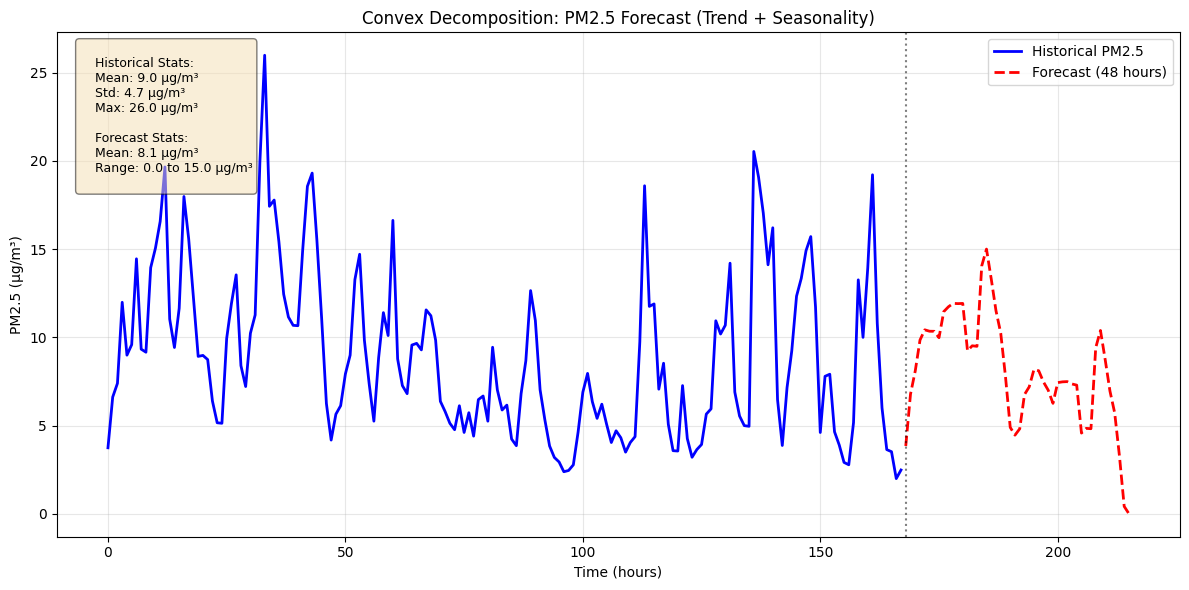

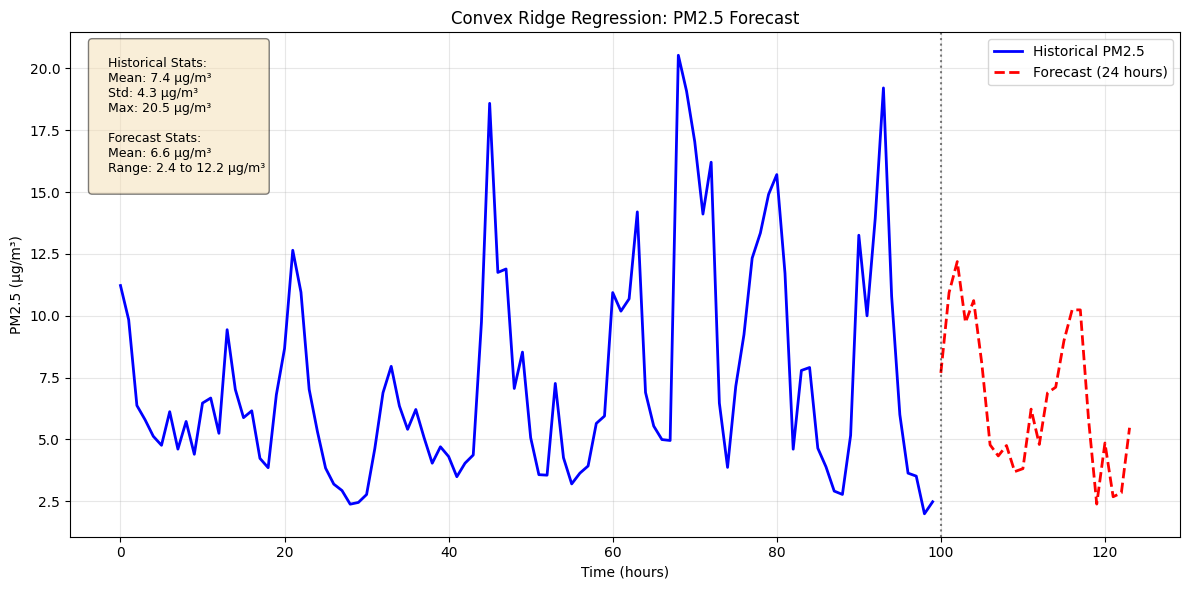

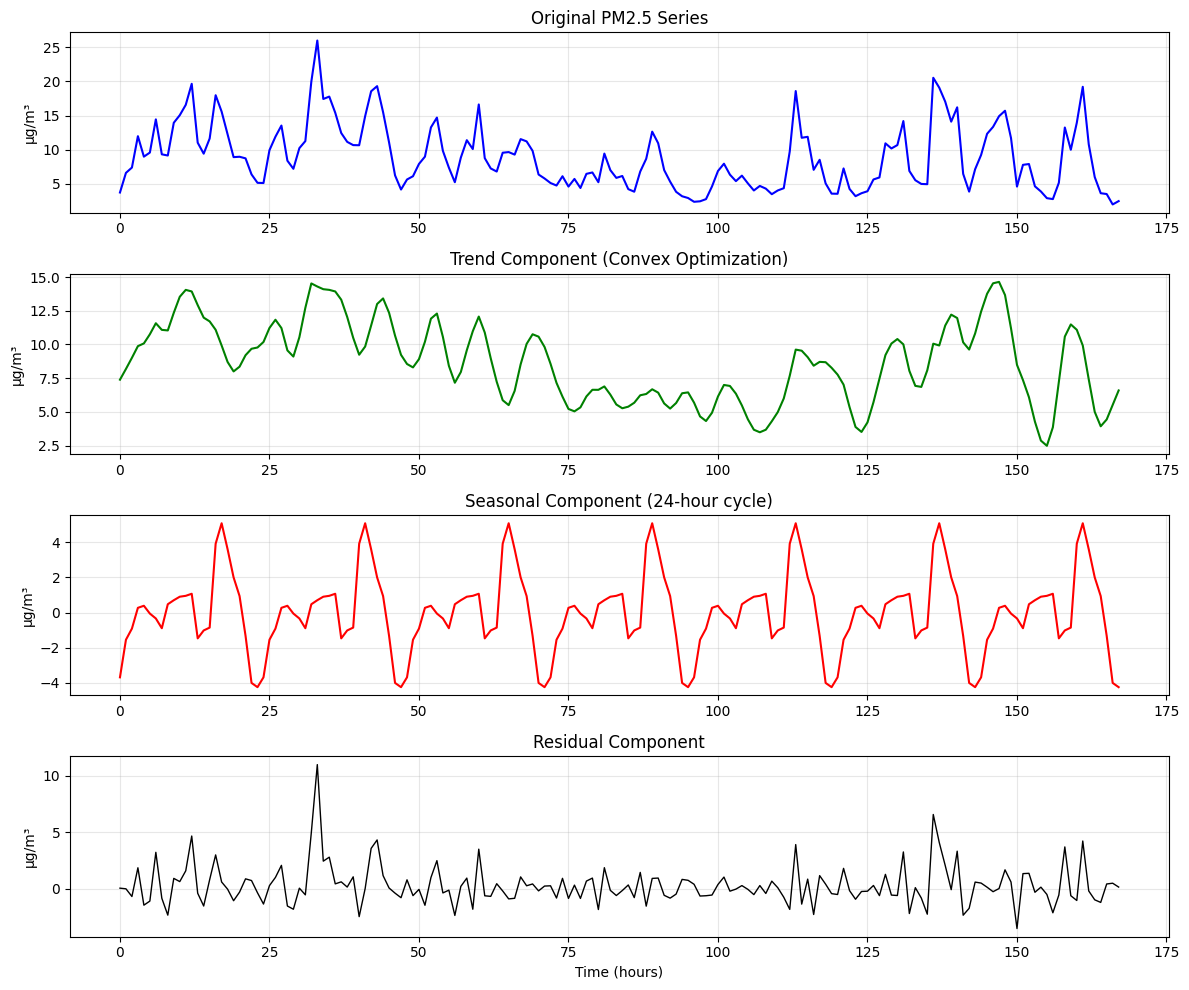


FORECAST SUMMARY

Decomposition Forecast (48 hours):
  Average: 8.1 µg/m³
  Minimum: 0.0 µg/m³
  Maximum: 15.0 µg/m³
  95th percentile: 12.8 µg/m³

Ridge Regression Forecast (24 hours):
  Average: 6.6 µg/m³
  Trend: Decreasing

⚠️  HEALTH ALERT: Forecast exceeds WHO guideline (15 µg/m³)
  Hours above limit: 1/48
  Maximum exceedance: 15.0 µg/m³


In [15]:
import cvxpy as cp
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. DATA PREPARATION (works with your df directly)
def prepare_pm25_data(df_input, sensor_id=57):
    """
    Extract and prepare PM2.5 time series for convex optimization
    """
    # Filter for specific sensor and sort by time
    sensor_data = df_input[df_input['sensor_id'] == sensor_id].copy()
    sensor_data = sensor_data.sort_values('timestamp')

    # Extract PM2.5 and forward fill missing values
    pm25_series = sensor_data['PM2_5'].ffill().dropna().values

    # Create time features
    timestamps = sensor_data.loc[sensor_data['PM2_5'].notna(), 'timestamp'].values
    hours = sensor_data.loc[sensor_data['PM2_5'].notna(), 'hour'].values
    days = sensor_data.loc[sensor_data['PM2_5'].notna(), 'day_of_week'].values

    print(f"PM2.5 time series length: {len(pm25_series)}")
    print(f"Range: {pm25_series.min():.1f} to {pm25_series.max():.1f} µg/m³")
    print(f"Mean: {pm25_series.mean():.1f} \u00b1 {pm25_series.std():.1f} µg/m³")

    return pm25_series, hours, days

# 2. CONVEX DECOMPOSITION MODEL (Trend + Seasonality)
def convex_air_quality_forecast(pm25_series, forecast_horizon=24, lambda_trend=1.0, lambda_seasonal=0.1):
    """
    Convex optimization for PM2.5 decomposition: y = trend + seasonal + residual
    Based on Hodrick-Prescott filter formulation
    """
    n = len(pm25_series)

    # Define variables
    trend = cp.Variable(n + forecast_horizon)
    seasonal = cp.Variable(n + forecast_horizon)

    # Constraints: Seasonality sums to zero over period (24 hours)
    period = 24
    constraints = []
    for i in range(n + forecast_horizon - period):
        constraints.append(cp.sum(seasonal[i:i+period]) == 0)
    constraints.append(trend + seasonal >= 0) # Ensure non-negativity of the baseline trend + seasonal

    # New constraint: enforce predictions to be below WHO guideline
    WHO_LIMIT = 15.0 # WHO 24-hour guideline for PM2.5
    constraints.append(trend + seasonal <= WHO_LIMIT) # Enforce forecast to be below WHO guideline

    # Objective: Fit observed data + smoothness penalties
    objective = cp.Minimize(
        cp.sum_squares(pm25_series - (trend[:n] + seasonal[:n])) +  # Fit to data
        lambda_trend * cp.sum_squares(cp.diff(trend, k=2)) +      # Trend smoothness
        lambda_seasonal * cp.sum_squares(seasonal[period:] - seasonal[:-period])  # Seasonal smoothness
    )

    # Solve the convex problem
    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.OSQP, verbose=True) # Changed solver to OSQP

    # Extract components
    trend_component = trend.value[:n]
    seasonal_component = seasonal.value[:n]
    residual = pm25_series - (trend_component + seasonal_component)

    # Forecast future values
    forecast = trend.value[n:] + seasonal.value[n:]
    forecast = np.maximum(0, forecast) # Clip forecast at zero to ensure non-negativity

    return forecast, trend_component, seasonal_component, residual

# 3. RIDGE REGRESSION FORECASTING (Alternative convex approach)
def convex_ridge_forecast(pm25_series, forecast_horizon=24, n_lags=24):
    """
    Convex ridge regression with lagged features
    """
    n = len(pm25_series)

    # Create lagged features matrix
    X = []
    y = []
    for i in range(n_lags, n - forecast_horizon): # Adjusted loop for safety
        X.append(pm25_series[i-n_lags:i])
        y.append(pm25_series[i:i+forecast_horizon])

    # Handle cases where not enough data for lags/forecast_horizon
    if not X or not y:
        print("Warning: Not enough data to create lagged features for ridge regression. Returning zeros.")
        return np.zeros(forecast_horizon), np.zeros((n_lags, forecast_horizon)), np.zeros(forecast_horizon)

    X = np.array(X)
    y = np.array(y)

    print(f"Training samples: {X.shape[0]}, Features: {X.shape[1]}, Horizon: {forecast_horizon}")

    # Define variables
    W = cp.Variable((n_lags, forecast_horizon))  # Weight matrix
    b = cp.Variable(forecast_horizon)            # Bias vector

    # Convex objective: Ridge regression
    objective = cp.Minimize(
        cp.sum_squares(X @ W + b - y) / len(X) +
        0.01 * cp.sum_squares(W)  # L2 regularization
    )

    # Solve
    problem = cp.Problem(objective)
    problem.solve(solver=cp.OSQP, verbose=False) # Changed solver to OSQP

    # Make forecast from last observation
    last_observation = pm25_series[-n_lags:]
    forecast = last_observation @ W.value + b.value
    forecast = np.maximum(0, forecast) # Clip forecast at zero to ensure non-negativity

    return forecast, W.value, b.value

# 4. VISUALIZATION
def plot_convex_forecast(historical, forecast, title="PM2.5 Convex Optimization Forecast"):
    """
    Plot historical data and convex forecast
    """
    plt.figure(figsize=(12, 6))

    # Historical data
    time_historical = np.arange(len(historical))
    plt.plot(time_historical, historical, 'b-', linewidth=2, label='Historical PM2.5')

    # Forecast
    time_forecast = np.arange(len(historical), len(historical) + len(forecast))
    plt.plot(time_forecast, forecast, 'r--', linewidth=2, label=f'Forecast ({len(forecast)} hours)')

    # Formatting
    plt.xlabel('Time (hours)')
    plt.ylabel('PM2.5 (µg/m³)')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.axvline(x=len(historical), color='k', linestyle=':', alpha=0.5)

    # Add statistics
    stats_text = f"""
    Historical Stats:
    Mean: {historical.mean():.1f} µg/m³
    Std: {historical.std():.1f} µg/m³
    Max: {historical.max():.1f} µg/m³

    Forecast Stats:
    Mean: {forecast.mean():.1f} µg/m³
    Range: {forecast.min():.1f} to {forecast.max():.1f} µg/m³
    """
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes,
             verticalalignment='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

# 5. MAIN EXECUTION
def main():
    """
    Main convex optimization pipeline
    """
    print("=" * 60)
    print("CONVEX OPTIMIZATION FOR AIR QUALITY FORECASTING")
    print("=" * 60)

    # --- Start Data Preparation within main() for robustness ---
    # Load df from CSV
    df = pd.read_csv('/content/data_encoded.csv')

    # Standard initial processing steps
    df["timestamp"] = pd.to_datetime(
        df["timestamp"],
        errors="coerce",   # invalid parsing → NaT
        utc=True           # handles +00:00 safely
    )
    df = df.dropna(subset=["timestamp"])
    df["timestamp"] = df["timestamp"].dt.tz_convert(None)

    # Split by sensor type
    df_pm = df[df["sensor_type"] == "SDS011"]
    df_met = df[df["sensor_type"] == "DHT22"]

    # Merge PM and meteorological data
    df_merged = pd.merge_asof(
        df_pm.sort_values("timestamp"),
        df_met.sort_values("timestamp"),
        on="timestamp",
        by=["location", "lat", "lon"],
        tolerance=pd.Timedelta("1min"),
        direction="nearest",
        suffixes=("", "_met")
    )

    # Select and rename columns for df_clean
    df_clean = df_merged[
        [
            "timestamp",
            "sensor_id",
            "lat",
            "lon",
            "PM2_5",
            "temperature_met",
            "humidity_met",
            "hour",
            "day_of_week"
        ]
    ].rename(columns={
        "temperature_met": "temperature",
        "humidity_met": "humidity"
    })
    # --- End Data Preparation within main() ---

    # Step 1: Prepare data
    print("\n1. PREPARING DATA...")
    # Use df_clean for pm25_series creation
    target_sensor_id_for_convex_ts = 57
    pm25_series_raw = df_clean[df_clean['sensor_id'] == target_sensor_id_for_convex_ts]
    pm25_series_hourly = pm25_series_raw.set_index('timestamp')['PM2_5'].resample('1h').mean().ffill().bfill() # Changed '1H' to '1h'
    pm25_series = pm25_series_hourly.values

    if len(pm25_series) < 100:
        print(f"Warning: Only {len(pm25_series)} data points. Need more for reliable forecasting.")

    # Use last week of data (168 hours) for demonstration
    sample_size = min(168, len(pm25_series))
    pm25_sample = pm25_series[-sample_size:]

    print(f"\nUsing last {sample_size} hours for forecasting")

    # Step 2: Run convex decomposition
    print("\n2. RUNNING CONVEX DECOMPOSITION...")
    forecast_horizon = 48  # Forecast 48 hours ahead

    forecast, trend, seasonal, residual = convex_air_quality_forecast(
        pm25_sample,
        forecast_horizon=forecast_horizon,
        lambda_trend=1.0,
        lambda_seasonal=0.1
    )

    print(f"\u2713 Convex decomposition completed")
    print(f"  Forecast length: {len(forecast)} hours")
    print(f"  Trend variance: {np.var(trend):.2f}")
    print(f"  Seasonal variance: {np.var(seasonal):.2f}")
    print(f"  Residual variance: {np.var(residual):.2f}")

    # Step 3: Run ridge regression (alternative approach)
    print("\n3. RUNNING CONVEX RIDGE REGRESSION...")
    ridge_forecast, W, b = convex_ridge_forecast(
        pm25_sample,
        forecast_horizon=min(24, forecast_horizon),  # Shorter horizon for ridge
        n_lags=24
    )

    print(f"\u2713 Ridge regression completed")
    print(f"  Weight matrix shape: {W.shape}")
    print(f"  Most important lags: {np.argsort(np.abs(W).sum(axis=1))[-3:]} hours")

    # Step 4: Visualize results
    print("\n4. VISUALIZING RESULTS...")

    # Plot 1: Convex decomposition forecast
    plot_convex_forecast(pm25_sample, forecast,
                        "Convex Decomposition: PM2.5 Forecast (Trend + Seasonality)")

    # Plot 2: Ridge regression forecast
    plot_convex_forecast(pm25_sample[-100:], ridge_forecast,
                        "Convex Ridge Regression: PM2.5 Forecast")

    # Plot 3: Decomposition components
    fig, axes = plt.subplots(4, 1, figsize=(12, 10))

    axes[0].plot(pm25_sample, 'b-', linewidth=1.5)
    axes[0].set_title('Original PM2.5 Series')
    axes[0].set_ylabel('µg/m³')
    axes[0].grid(alpha=0.3)

    axes[1].plot(trend, 'g-', linewidth=1.5)
    axes[1].set_title('Trend Component (Convex Optimization)')
    axes[1].set_ylabel('µg/m³')
    axes[1].grid(alpha=0.3)

    axes[2].plot(seasonal, 'r-', linewidth=1.5)
    axes[2].set_title('Seasonal Component (24-hour cycle)')
    axes[2].set_ylabel('µg/m³')
    axes[2].grid(alpha=0.3)

    axes[3].plot(residual, 'k-', linewidth=1)
    axes[3].set_title('Residual Component')
    axes[3].set_ylabel('µg/m³')
    axes[3].set_xlabel('Time (hours)')
    axes[3].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Step 5: Print summary statistics
    print("\n" + "=" * 60)
    print("FORECAST SUMMARY")
    print("=" * 60)

    print(f"\nDecomposition Forecast (48 hours):")
    print(f"  Average: {forecast.mean():.1f} µg/m³")
    print(f"  Minimum: {forecast.min():.1f} µg/m³")
    print(f"  Maximum: {forecast.max():.1f} µg/m³")
    print(f"  95th percentile: {np.percentile(forecast, 95):.1f} µg/m³")

    print(f"\nRidge Regression Forecast (24 hours):")
    print(f"  Average: {ridge_forecast.mean():.1f} µg/m³")
    print(f"  Trend: {'Increasing' if ridge_forecast[-1] > ridge_forecast[0] else 'Decreasing'}")

    # Check for health thresholds
    who_limit = 15  # WHO 24-hour guideline
    exceedances = forecast[forecast > who_limit]
    if len(exceedances) > 0:
        print(f"\n\u26a0\ufe0f  HEALTH ALERT: Forecast exceeds WHO guideline ({who_limit} µg/m³)")
        print(f"  Hours above limit: {len(exceedances)}/{len(forecast)}")
        print(f"  Maximum exceedance: {exceedances.max():.1f} µg/m³")



# Run the analysis
if __name__ == "__main__":
    main()